In [1]:
from sklearn.datasets import fetch_olivetti_faces
olivetti = fetch_olivetti_faces()
print(olivetti.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

In [2]:
olivetti.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

In [3]:
X = olivetti.data
y = olivetti.target

In [4]:
import numpy as np
np.sqrt(4096) , X.shape

(np.float64(64.0), (400, 4096))

In [5]:
round(X[-1].min()), round(X[-1].max())

(0, 1)

In [6]:
# 데이터 분할
from collections import Counter
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test \
    = train_test_split(X,y,test_size=0.4,stratify=y,random_state=42)

In [7]:
# 연산속도 높이기  PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=0.99)
x_train_pca =  pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
pca.n_components_

np.int64(177)

In [8]:
# kmeans로 군집을 구분
# 최적의 k개수
# DBSCAN
# 계층적 군집화

In [9]:
# k평균 군집화
# OMP_NUM_THREADS=1  환경셋팅
import os
os.environ["OMP_NUM_THREADS"] = '1'

c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\c

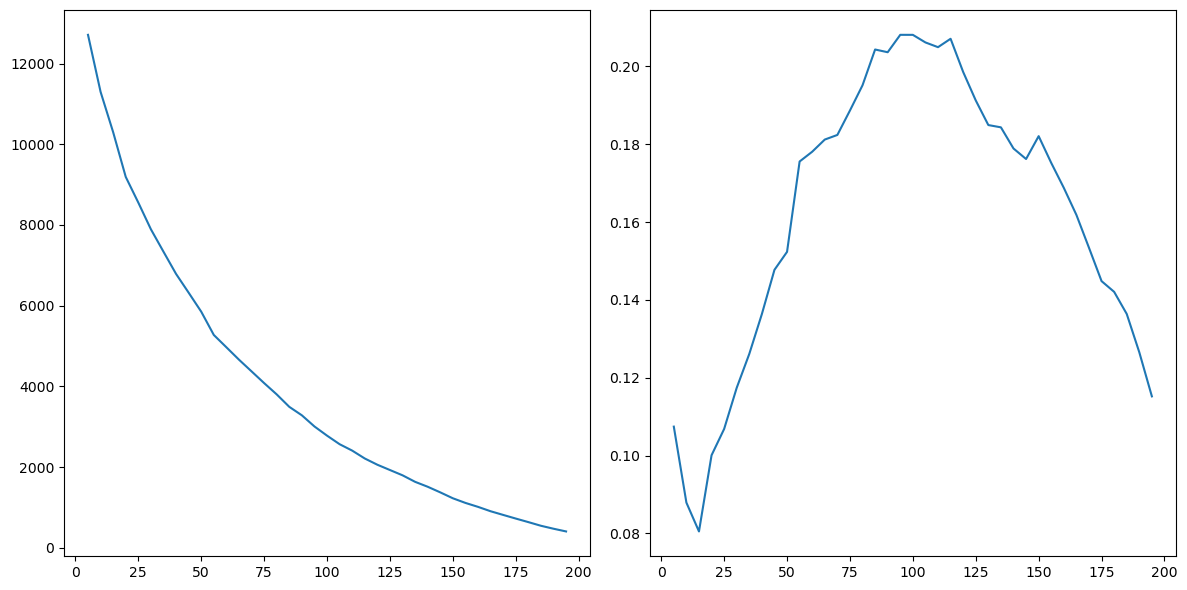

실루엣 최고점수의 인덱스 : 95


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
k_range = range(5,200,5)
ellow = []
sillhouet_scores = []
for k in k_range:
    km = KMeans(n_clusters=k,random_state=42)
    km.fit(x_train_pca)
    
    sillhouet_scores.append(silhouette_score(x_train_pca, km.labels_))
    ellow.append(km.inertia_)

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].plot(k_range,ellow )
ax[1].plot(k_range,sillhouet_scores)
plt.tight_layout()
plt.show()

print(f'실루엣 최고점수의 인덱스 : {k_range[np.argmax(sillhouet_scores)] }')

label = 0


c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


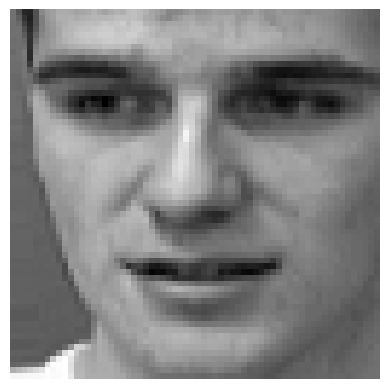

label = 1


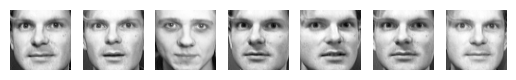

label = 2


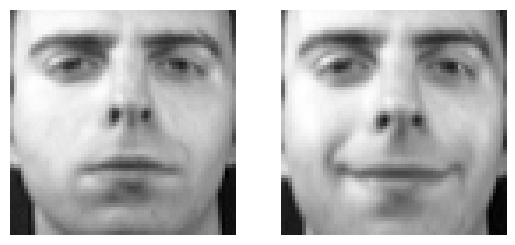

label = 3


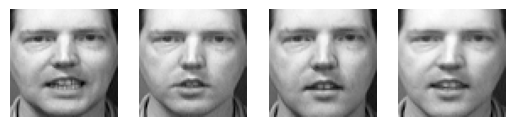

label = 4


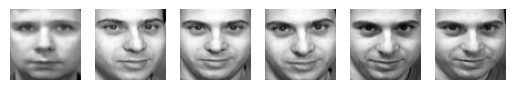

label = 5


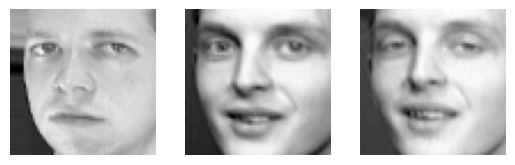

label = 6


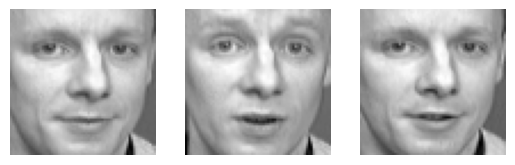

label = 7


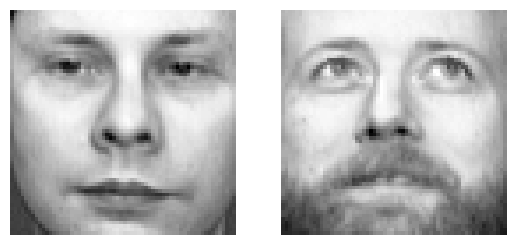

label = 8


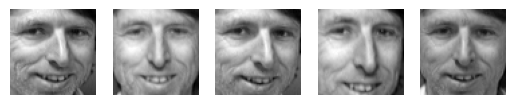

label = 9


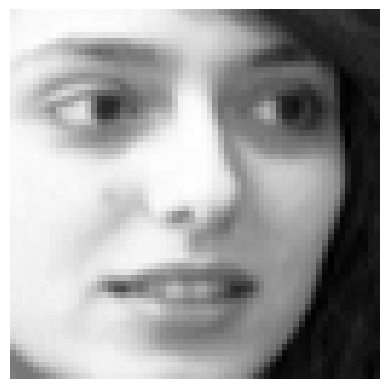

label = 10


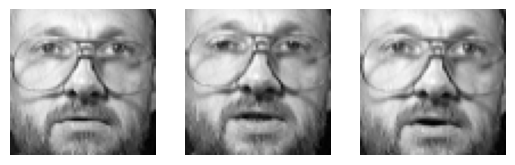

label = 11


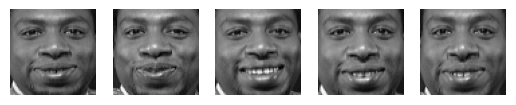

label = 12


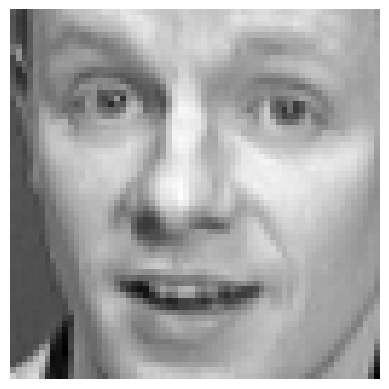

label = 13


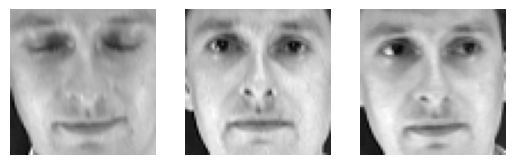

label = 14


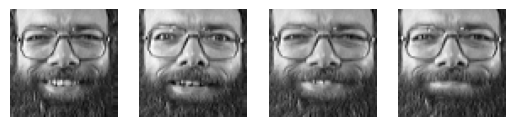

label = 15


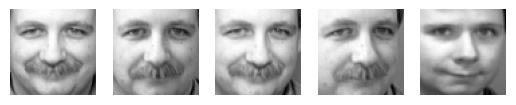

label = 16


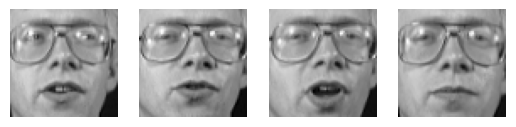

label = 17


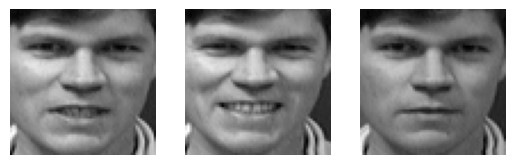

label = 18


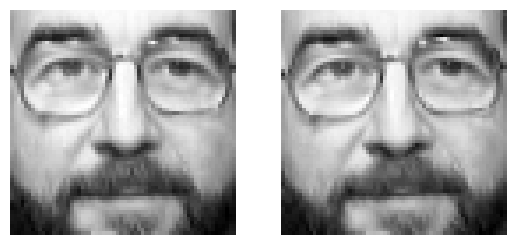

label = 19


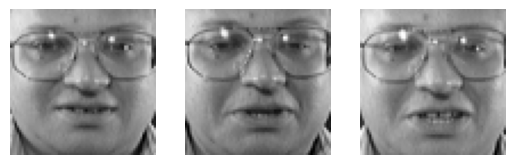

label = 20


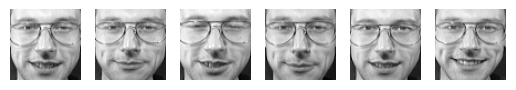

label = 21


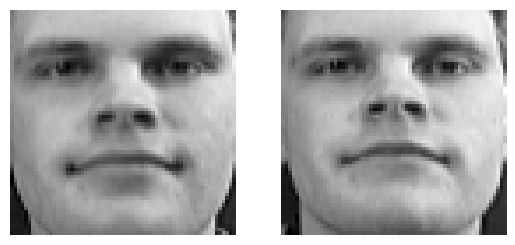

label = 22


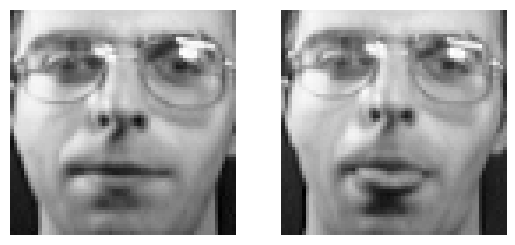

label = 23


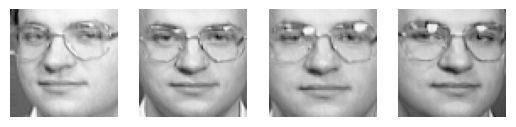

label = 24


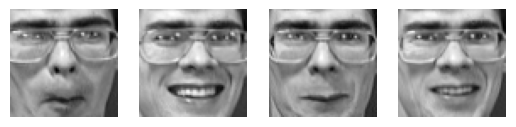

label = 25


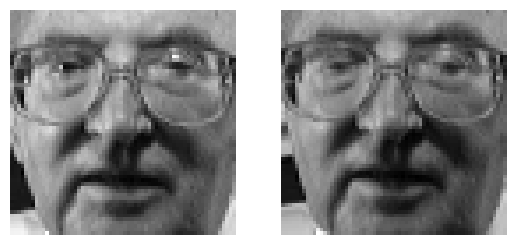

label = 26


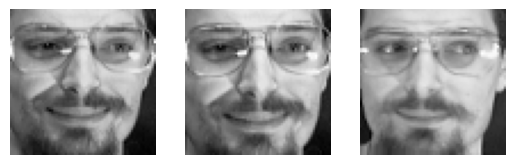

label = 27


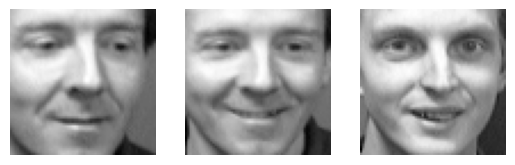

label = 28


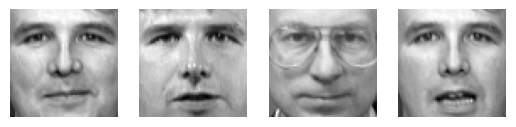

label = 29


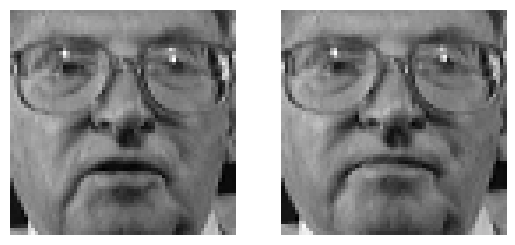

label = 30


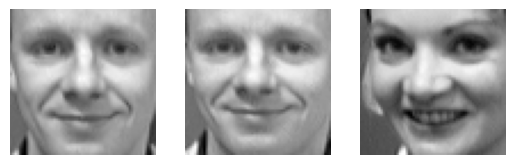

label = 31


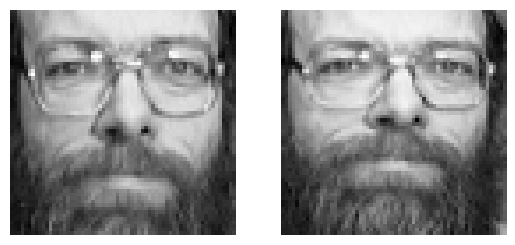

label = 32


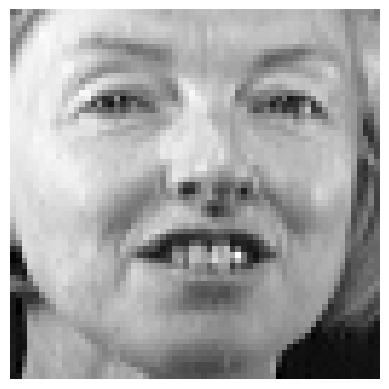

label = 33


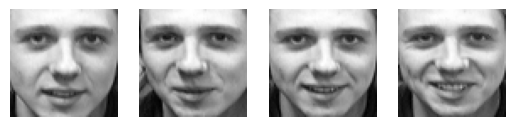

label = 34


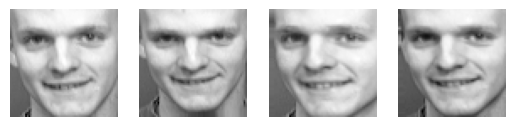

label = 35


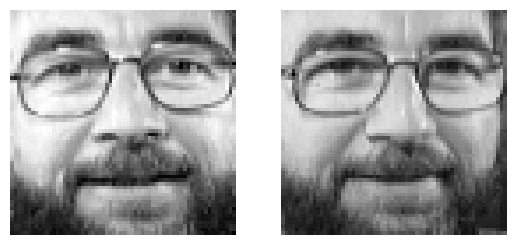

label = 36


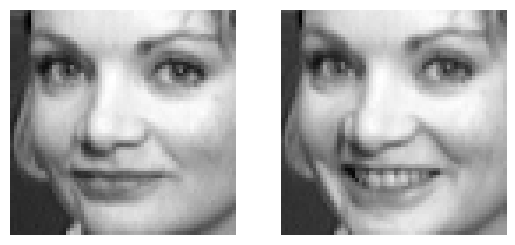

label = 37


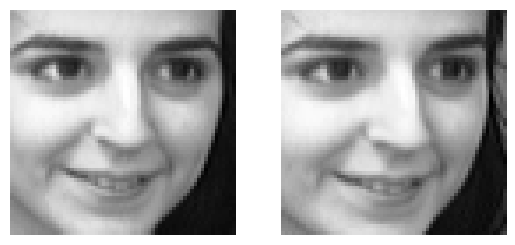

label = 38


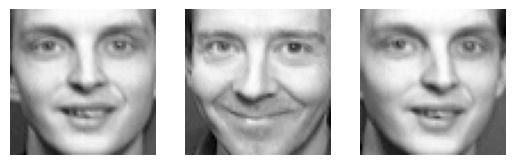

label = 39


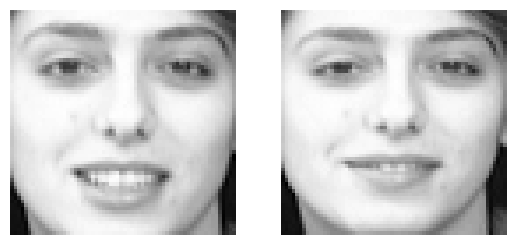

label = 40


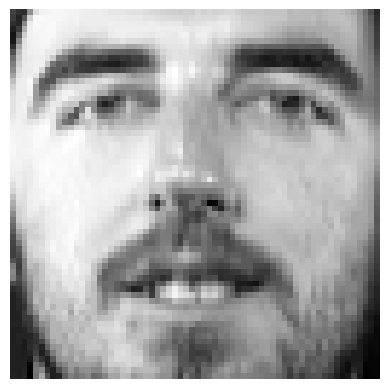

label = 41


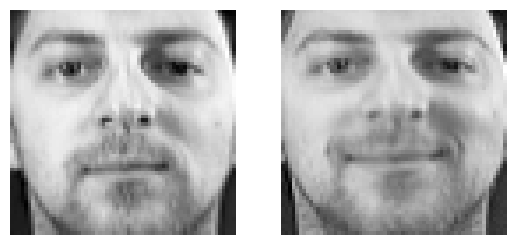

label = 42


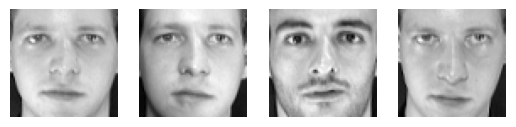

label = 43


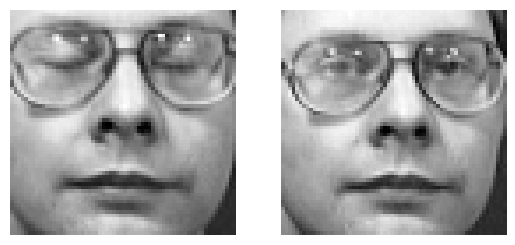

label = 44


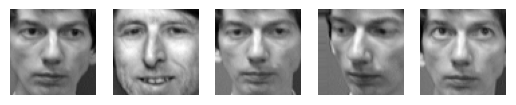

label = 45


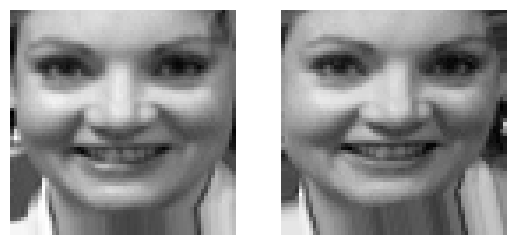

label = 46


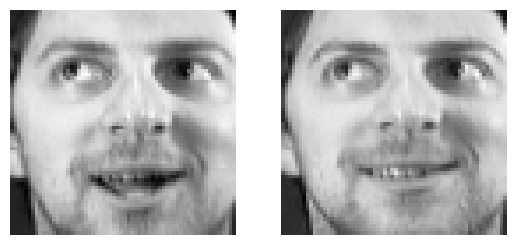

label = 47


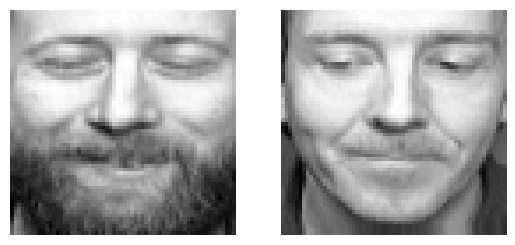

label = 48


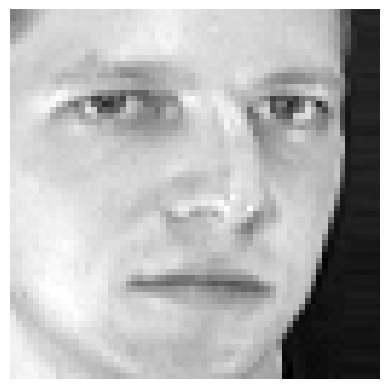

label = 49


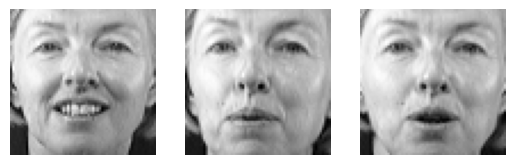

label = 50


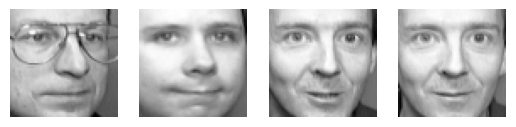

label = 51


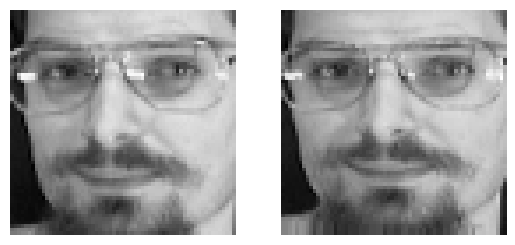

label = 52


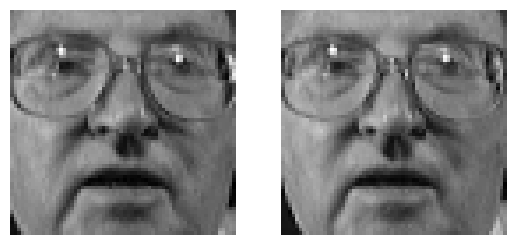

label = 53


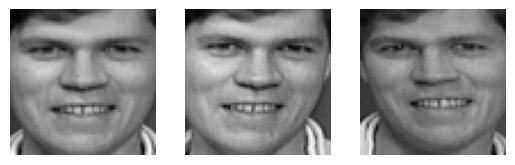

label = 54


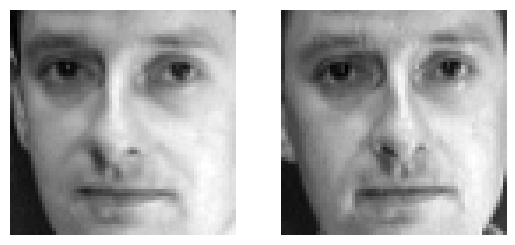

label = 55


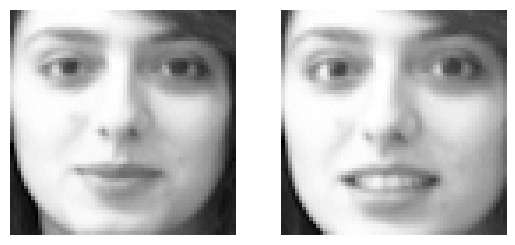

label = 56


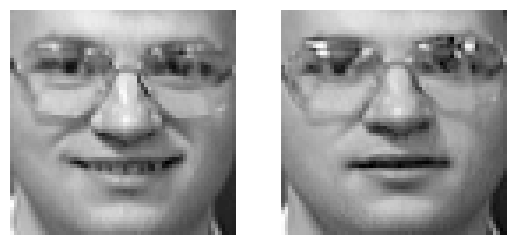

label = 57


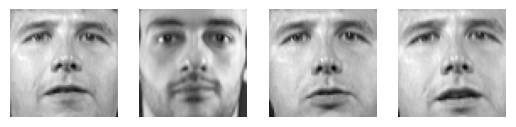

label = 58


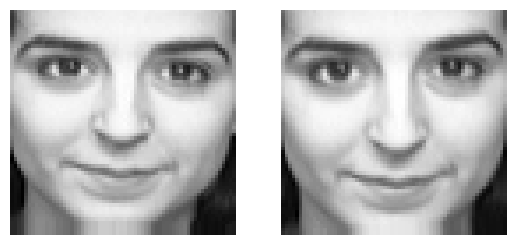

label = 59


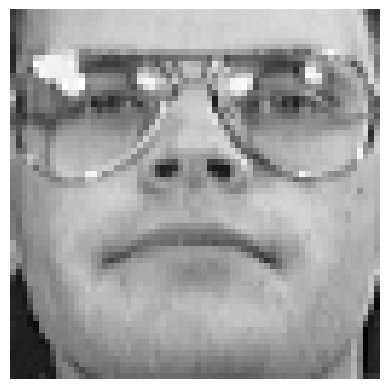

label = 60


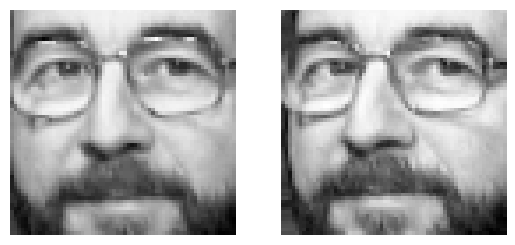

label = 61


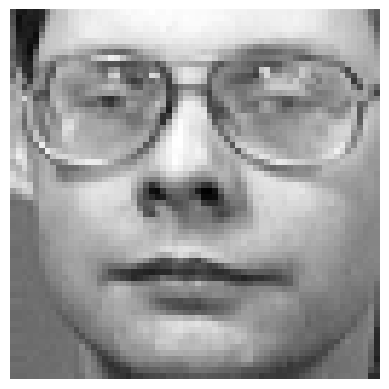

label = 62


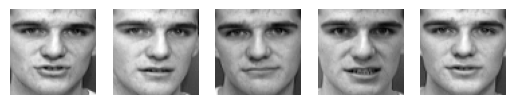

label = 63


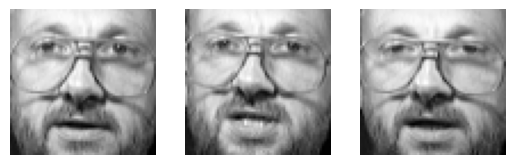

label = 64


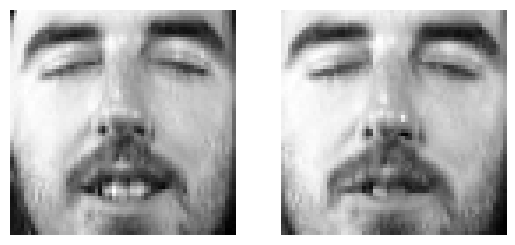

label = 65


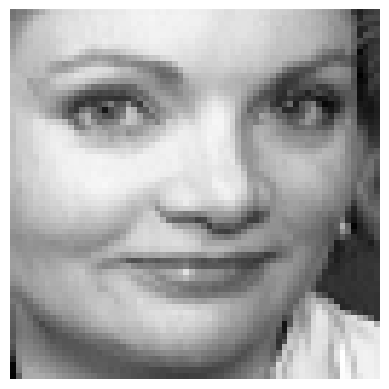

label = 66


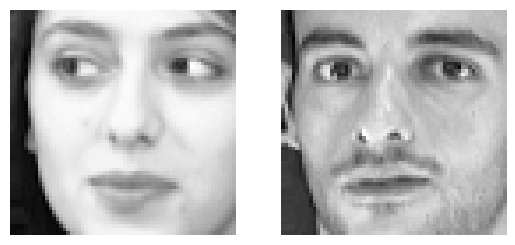

label = 67


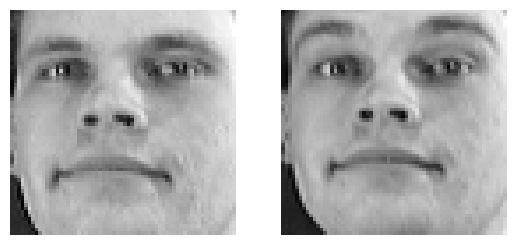

label = 68


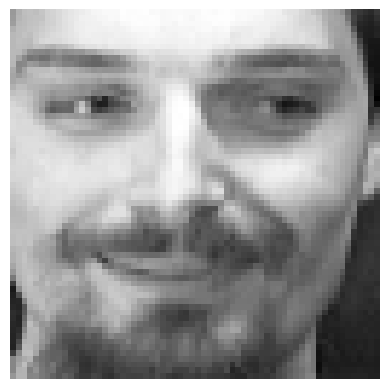

label = 69


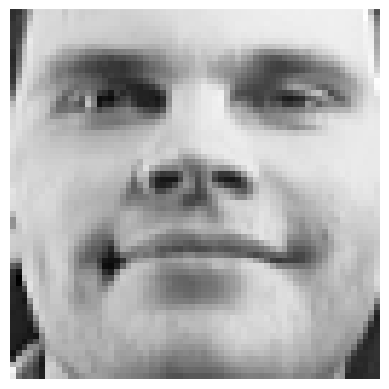

label = 70


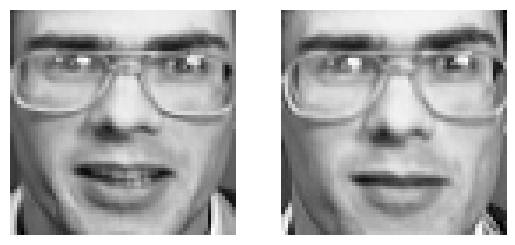

label = 71


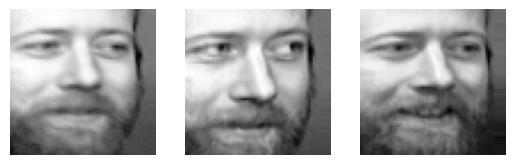

label = 72


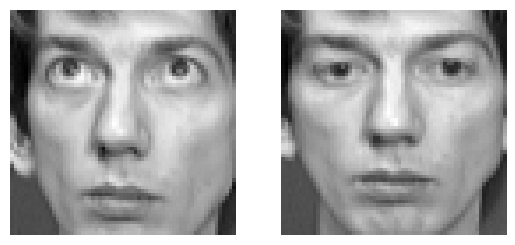

label = 73


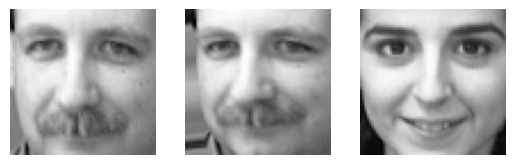

label = 74


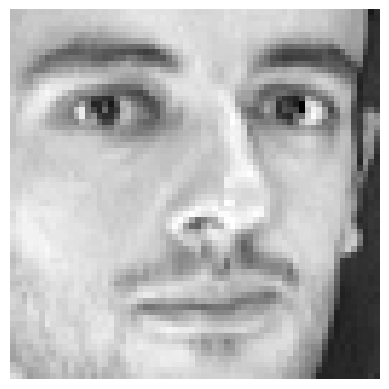

label = 75


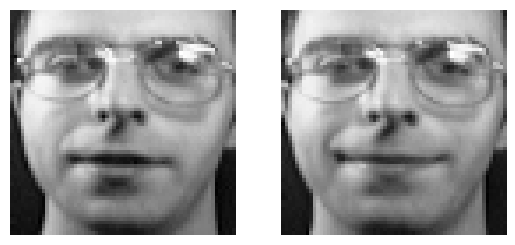

label = 76


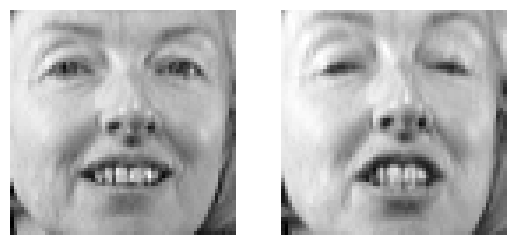

label = 77


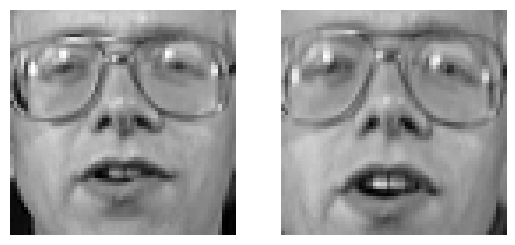

label = 78


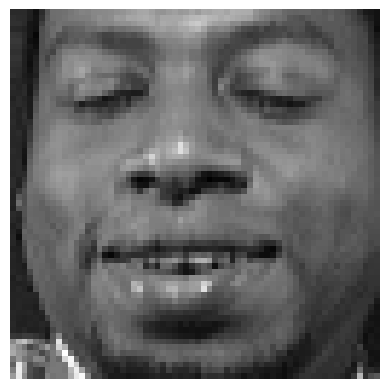

label = 79


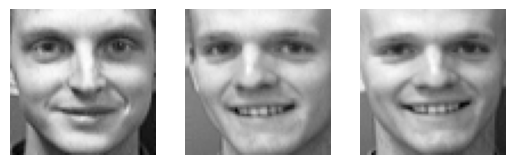

label = 80


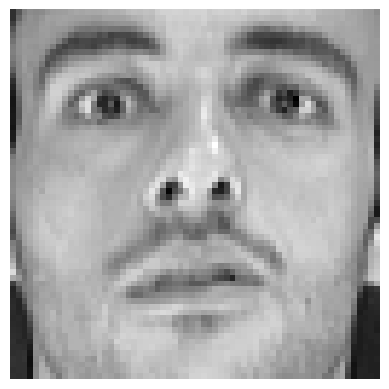

label = 81


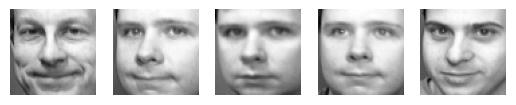

label = 82


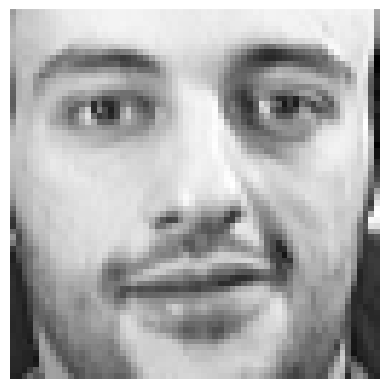

label = 83


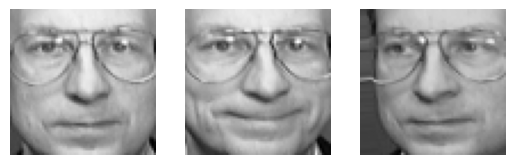

label = 84


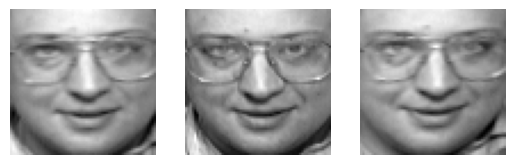

label = 85


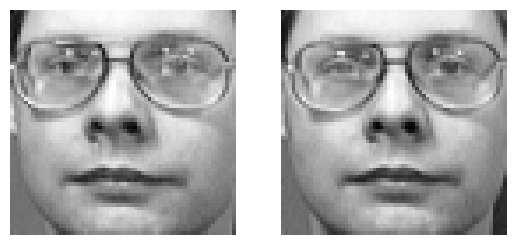

label = 86


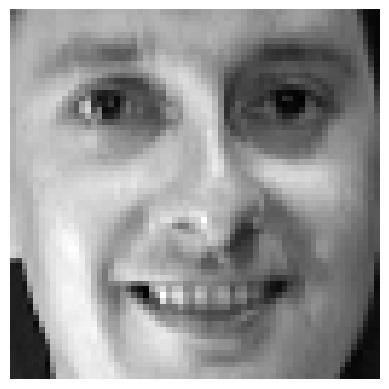

label = 87


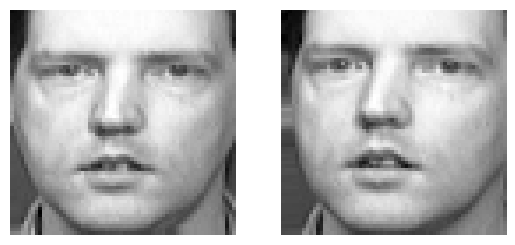

label = 88


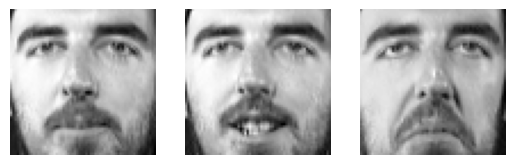

label = 89


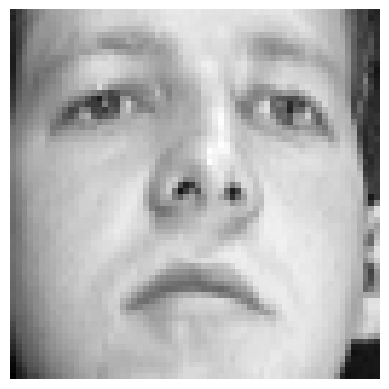

label = 90


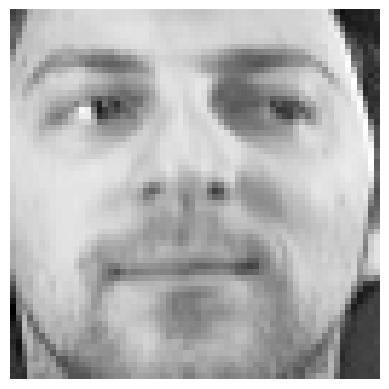

label = 91


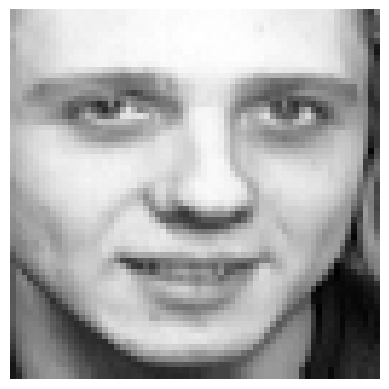

label = 92


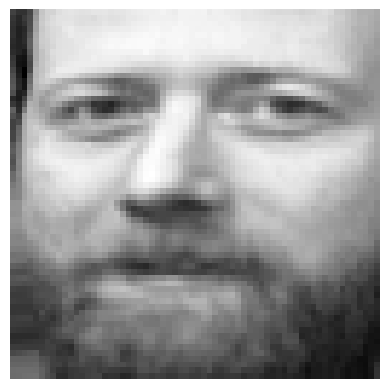

label = 93


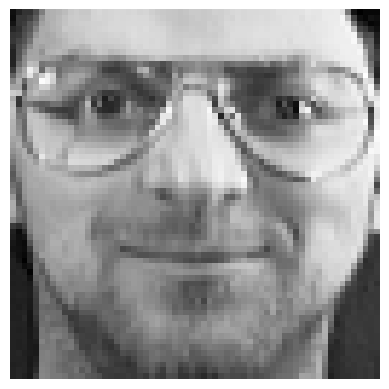

label = 94


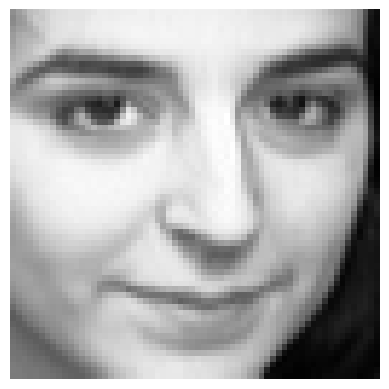

In [97]:
cluster = 95 
from sklearn.cluster import KMeans
km = KMeans(n_clusters=cluster,random_state=42)
km.fit(x_train_pca)

for c_label in np.unique(km.labels_):

    print(f'label = {c_label}')
    row_count = x_train[km.labels_ == c_label].shape[0]

    show_images = x_train[km.labels_ == c_label]

    for idx in range(row_count):
        plt.subplot(1,row_count,idx+1)
        plt.imshow(show_images[idx].reshape(64,64),cmap='gray')    
        plt.axis('off')
    plt.show()


In [100]:
# 분류기 
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=200, random_state=42)
rfc.fit(x_train_pca, y_train)
rfc.score(x_test_pca, y_test)

0.90625

In [103]:
# 새로운 라벨링   k평균을 차원축소 도구로 사용
x_train_reduced = km.transform(x_train_pca)
x_test_reduced =  km.transform(x_test_pca)
clf = RandomForestClassifier(n_estimators=200,random_state=42)
clf.fit(x_train_reduced, y_train)
clf.score(x_test_reduced,y_test)

0.73125

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
pipeline =  Pipeline([
    ('pca',PCA(n_components=0.99,random_state=42)),
    ('cluster',KMeans(random_state=42)),
    ('rfc',RandomForestClassifier(n_estimators=200,random_state=42))
])
k_range = range(5, 200, 5)
scores = []
for k in k_range:
    pipeline.set_params(cluster__n_clusters=k)
    pipeline.fit(x_train, y_train)
    scores.append(pipeline.score(x_test,y_test))

max_index = np.argmax(scores)    
print(f'정확도 : {np.max(scores)} 클러스터개수 : {k_range[max_index]} ')

In [128]:
# dbscan
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test \
    = train_test_split(X,y,random_state=42,test_size=0.25,stratify=y)
pca = PCA(n_components=2,random_state=42)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
print(f'conponet : {pca.n_components_}')
dbscan = DBSCAN(eps=5, min_samples=5)
dbscan.fit(x_train_pca)
dbscan.labels_

conponet : 2


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
from sklearn.cluster import AgglomerativeClustering
model_average = AgglomerativeClustering(n_clusters=5, linkage='average')


,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",5
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'average'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


In [ ]:
n_clusters = 100
import sklearn
from sklearn.cluster import AgglomerativeClustering
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
pca = PCA(n_components=0.99,random_state=42)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
model_average = AgglomerativeClustering(n_clusters=100, linkage='average')
y_train_pca_cluster = model_average.fit_predict(x_train_pca)
rfc = RandomForestClassifier(n_estimators=200,random_state=42)
rfc.fit(x_train_pca, y_train_pca_cluster)
y_test_predict = rfc.predict(x_test_pca)
rfc.score(x_test_pca, y_test_predict)

1.0